In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '/home/jbreda/PROseq/scripts/Phase_to_LabColor')
from phase_to_labcolor import phase_to_labcolor as p2lc

In [2]:
genome = 'GRCm38'

# get gene gtf
infile_gtf = f"../resources/genome/{genome}/gene_annotation.gtf"
gene_gtf = pd.read_csv(infile_gtf, sep='\t', comment='#', header=None)
gene_gtf.columns = ['chrom','source','feature','start','end','score','strand','frame','attributes']
# parse the gtf's 9 th column (attributes sep by ;)
attributes = ['gene_id','gene_type','gene_name','transcript_id','transcript_type','transcript_name']
for att in attributes:
    gene_gtf[att] = gene_gtf['attributes'].str.extract(rf'{att} "(.*?)";')



# get extended kalman filter data
bin_size = 1000
infile_kalman = f"../results/{genome}/kalman/extended_kalman_on_chromosomes_bin{bin_size}bp.csv"
extended = pd.read_csv(infile_kalman, sep='\t')

# get bin phase amplitude
infile_bin_fw = f"../results/{genome}/phase_amp/bin_phase_amp_forward_10000bp.csv"
infile_bin_rv = f"../results/{genome}/phase_amp/bin_phase_amp_reverse_10000bp.csv"
bin_phase_amp = {}
bin_phase_amp['+'] = pd.read_csv(infile_bin_fw, sep='\t')
bin_phase_amp['-'] = pd.read_csv(infile_bin_rv, sep='\t')

# read gene phase amplitude
#infile_gene = f"../results/{genome}/phase_amp/gene_phase_amp.csv"
#gene_phase_amp = {}
#gene_phase_amp['proseq'] = pd.read_csv(infile_gene, sep='\t')



In [5]:
gene_gtf

,chrom,source,feature,start,end,score,strand,frame,attributes,gene_id,gene_type,gene_name,transcript_id,transcript_type,transcript_name
0,chr1,HAVANA,gene,3073253,3074322,.,+,.,"gene_id ""ENSMUSG00000102693.1""; gene_type ""TEC...",ENSMUSG00000102693.1,TEC,4933401J01Rik,NaN,NaN,NaN
1,chr1,HAVANA,transcript,3073253,3074322,.,+,.,"gene_id ""ENSMUSG00000102693.1""; transcript_id ...",ENSMUSG00000102693.1,TEC,4933401J01Rik,ENSMUST00000193812.1,TEC,4933401J01Rik-201
2,chr1,HAVANA,exon,3073253,3074322,.,+,.,"gene_id ""ENSMUSG00000102693.1""; transcript_id ...",ENSMUSG00000102693.1,TEC,4933401J01Rik,ENSMUST00000193812.1,TEC,4933401J01Rik-201
3,chr1,ENSEMBL,gene,3102016,3102125,.,+,.,"gene_id ""ENSMUSG00000064842.1""; gene_type ""snR...",ENSMUSG00000064842.1,snRNA,Gm26206,NaN,NaN,NaN
4,chr1,ENSEMBL,transcript,3102016,3102125,.,+,.,"gene_id ""ENSMUSG00000064842.1""; transcript_id ...",ENSMUSG00000064842.1,snRNA,Gm26206,ENSMUST00000082908.1,snRNA,Gm26206-201
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1869218,JH584304.1,ENSEMBL,stop_codon,55480,55482,.,-,0,"gene_id ""ENSMUSG00000095041.7""; transcript_id ...",ENSMUSG00000095041.7,protein_coding,AC149090.1,ENSMUST00000178343.1,protein_coding,AC149090.1-202
1869219,JH584304.1,ENSEMBL,exon,52691,54867,.,-,.,"gene_id ""ENSMUSG00000095041.7""; transcript_id ...",ENSMUSG00000095041.7,protein_coding,AC149090.1,ENSMUST00000178343.1,protein_coding,AC149090.1-202
1869220,JH584304.1,ENSEMBL,UTR,58617,59690,.,-,.,"gene_id ""ENSMUSG00000095041.7""; transcript_id ...",ENSMUSG00000095041.7,protein_coding,AC149090.1,ENSMUST00000178343.1,protein_coding,AC149090.1-202
1869221,JH584304.1,ENSEMBL,UTR,55112,55482,.,-,.,"gene_id ""ENSMUSG00000095041.7""; transcript_id ...",ENSMUSG00000095041.7,protein_coding,AC149090.1,ENSMUST00000178343.1,protein_coding,AC149090.1-202


/tmp/ipykernel_444275/3496515499.py:136: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([str(round(a*1e-6,2)) for a in ax.get_xticks()])
/tmp/ipykernel_444275/3496515499.py:136: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([str(round(a*1e-6,2)) for a in ax.get_xticks()])
/tmp/ipykernel_444275/3496515499.py:136: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([str(round(a*1e-6,2)) for a in ax.get_xticks()])
/tmp/ipykernel_444275/3496515499.py:136: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([str(round(a*1e-6,2)) for a in ax.get_xticks()])
/tmp/ipykernel_444275/3496515499.py:136: Use

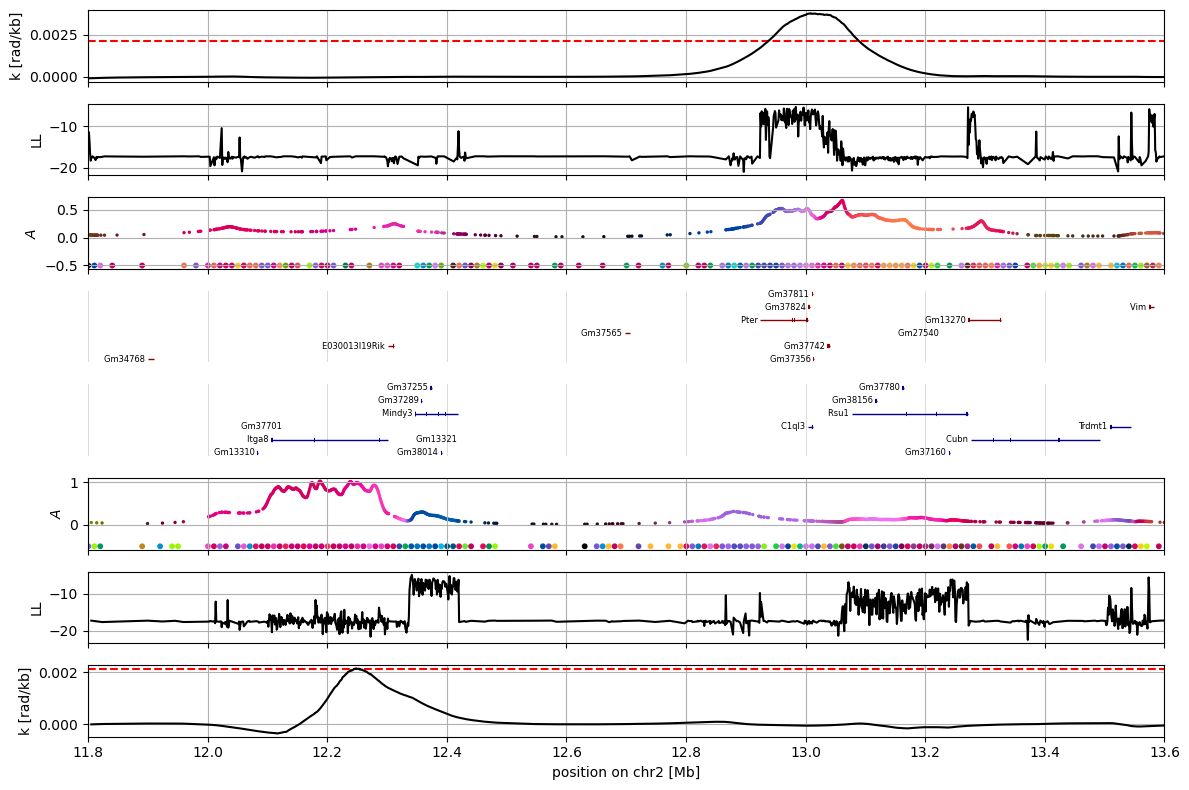

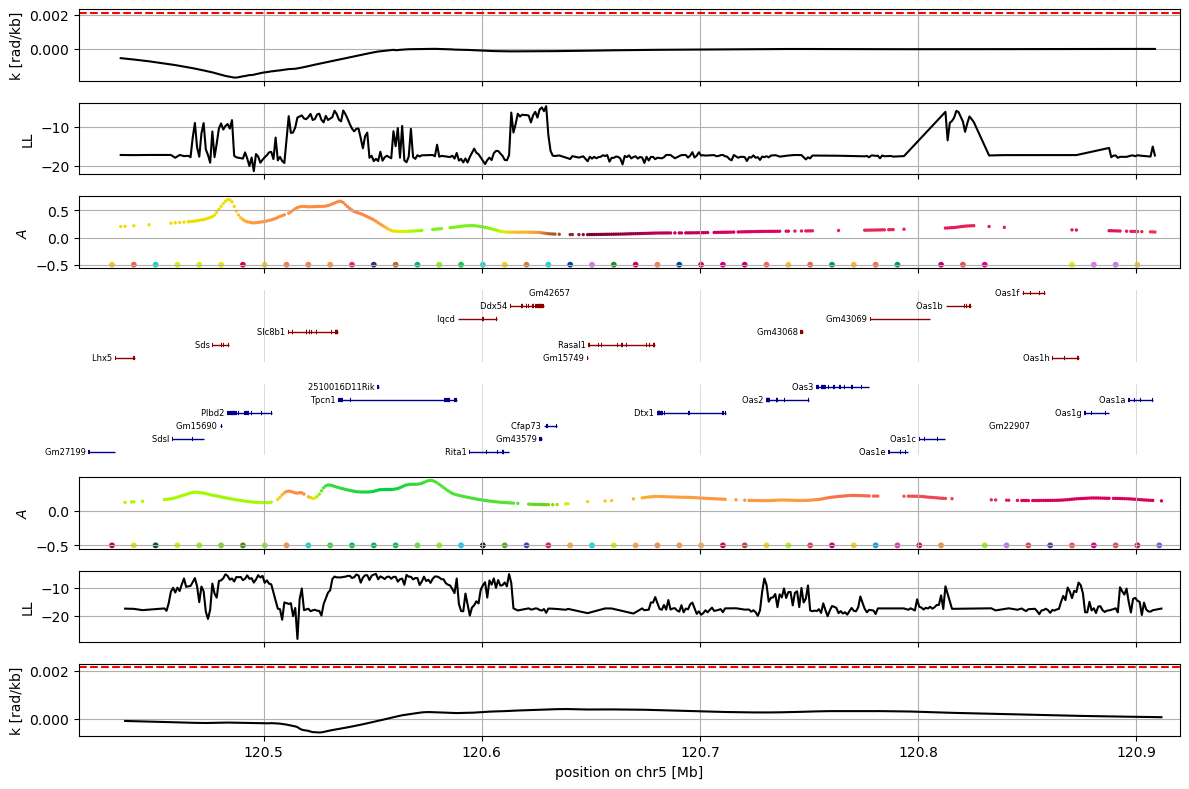

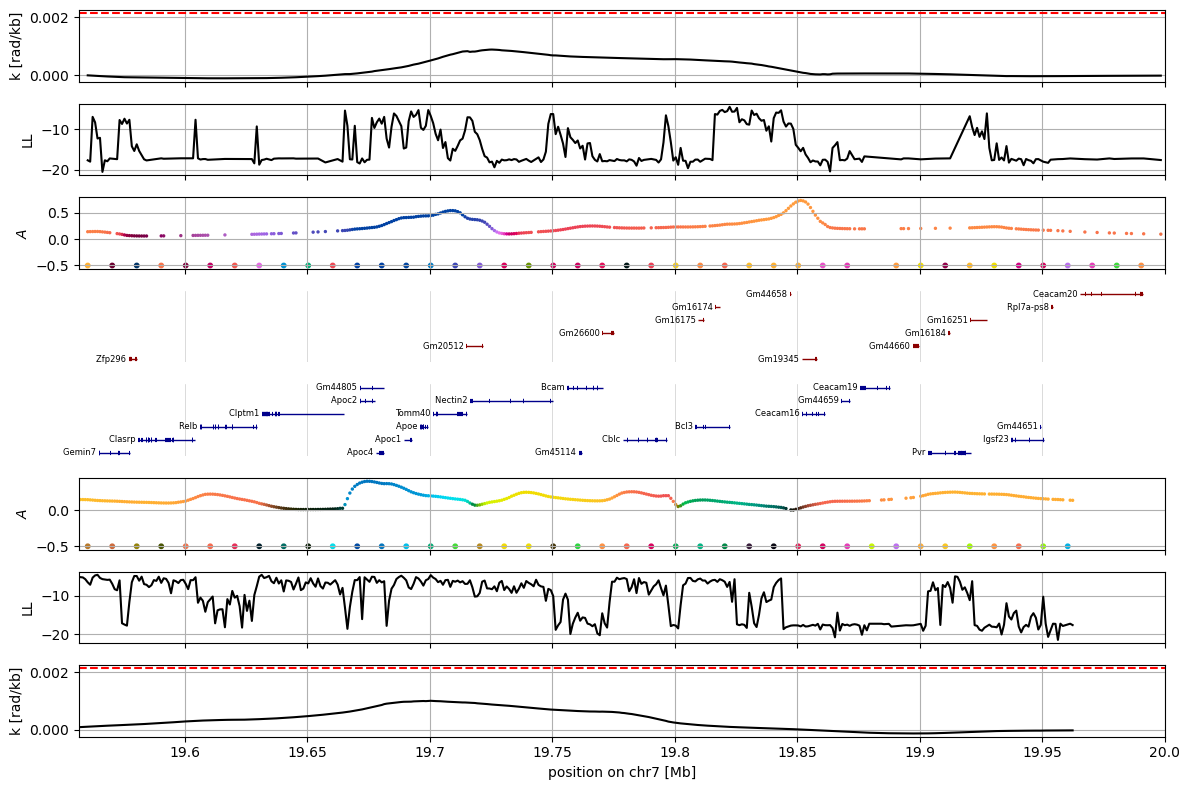

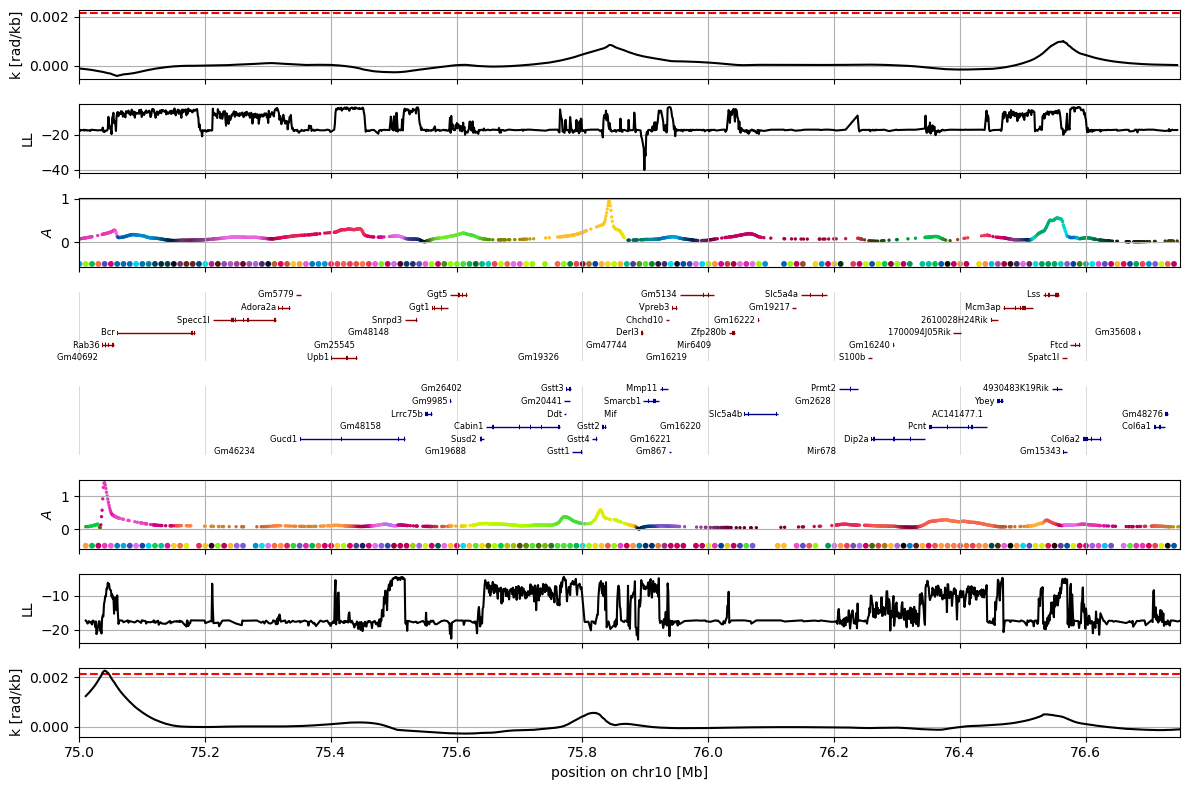

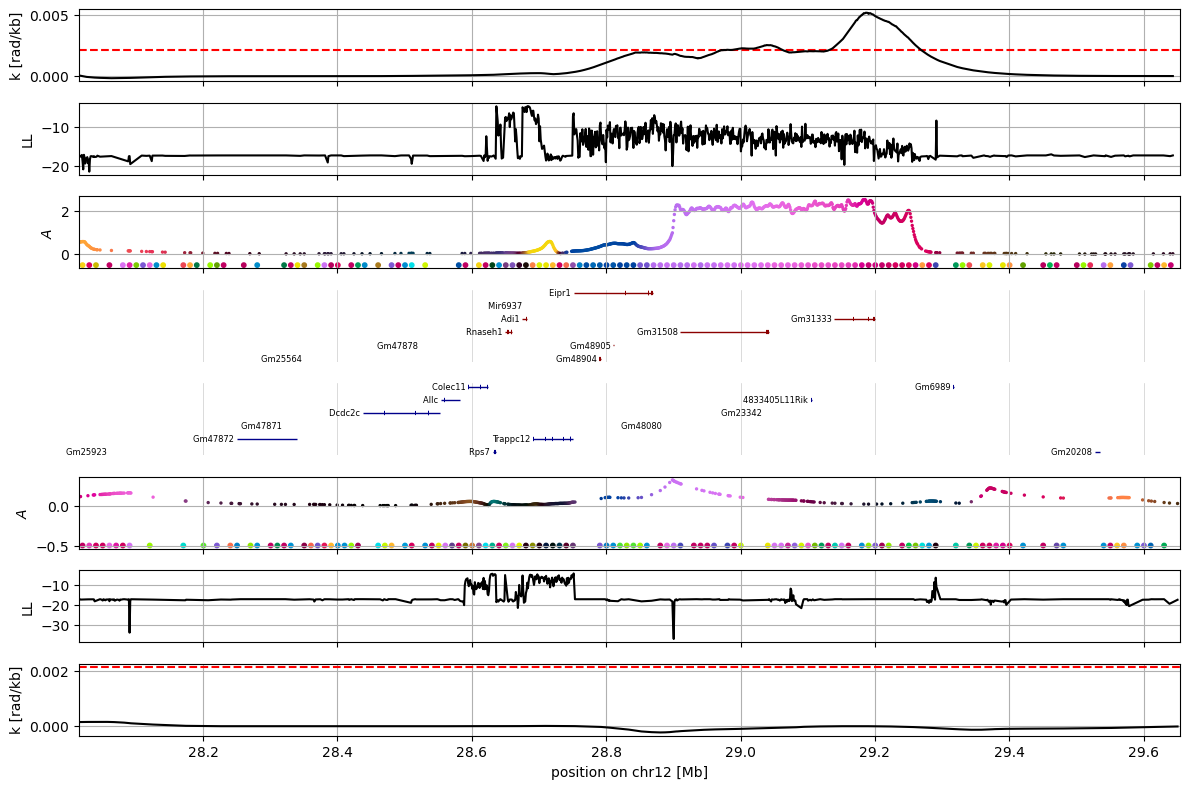

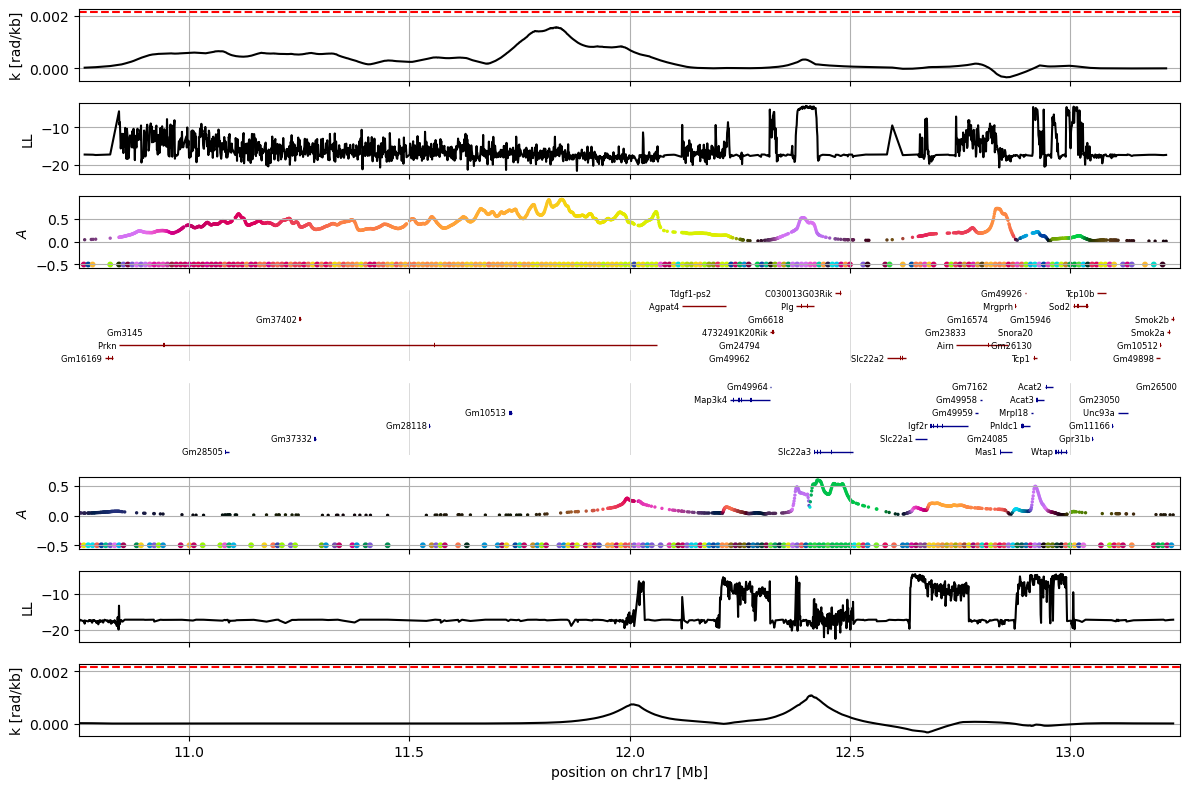

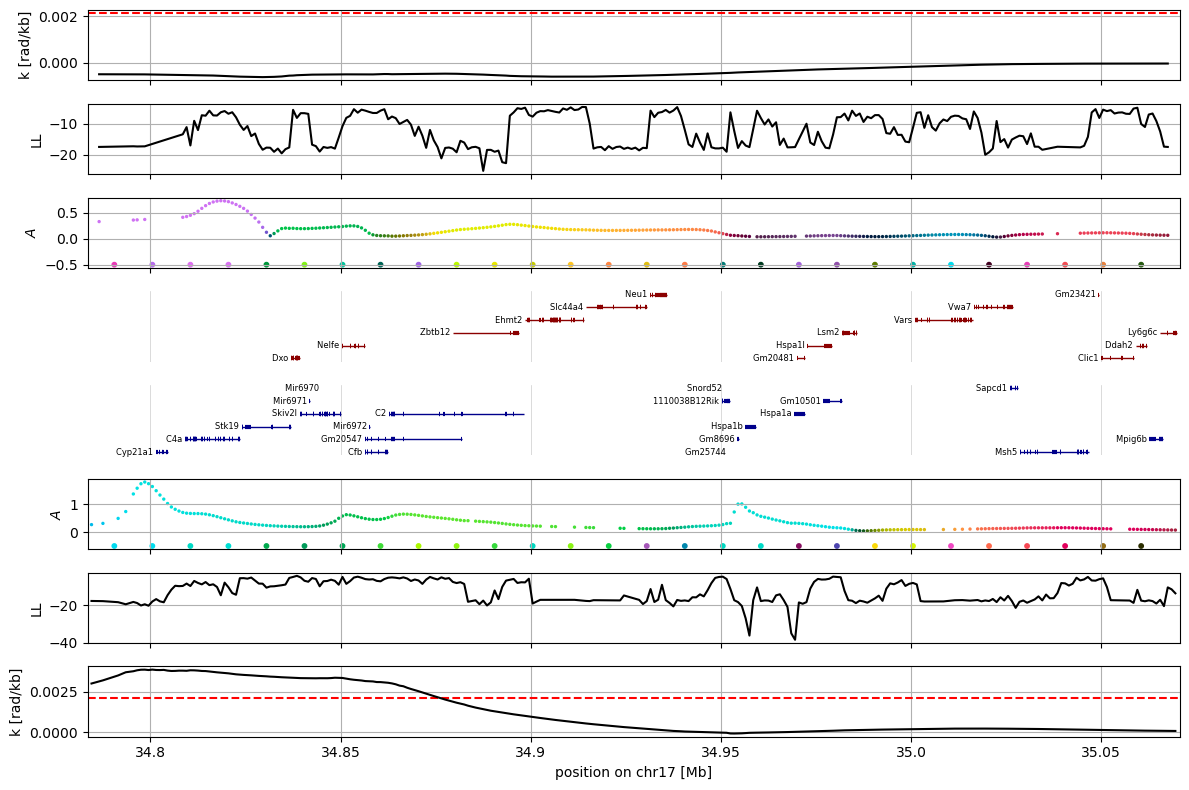

In [38]:
# removed regions :
# 'chr5:104_888_056:107_620_085',
# 'chr5:121_017_471:126_000_000',

Regions = ['chr2:11_800_000:13_600_000',
           'chr5:120_415_452:120_920_000',
           'chr7:19_557_000:20_000_000',
           'chr10:75_000_000:76_750_000',
           'chr12:28015438:29654150',
           'chr17:10_750_000:13_250_000',
           'chr17:34_783_585:35_070_714']

# k mean
ω = 2*np.pi/24 #  [rad/h] 
v_mean = 34 # [bp/s]
v_mean *= 1e-3 # [kb/s]
v_mean *= 3600 # [kb/h]
k_mean = ω/v_mean # [rad/kb]

for region in Regions:
    chrom, start, end = region.split(':')
    start = int(start)
    end = int(end)
    
    # plot : 2 strands * (k, phase, LL, genes)
    N_tracks = 4
    fig, axes = plt.subplots(nrows=2*N_tracks, ncols=1, figsize=(12, 8))
    fplus = N_tracks-1
    fminus = N_tracks
    for strand in ['+','-']:

        region_data = extended[(extended['chr'] == chrom) & (extended['start'] >= start) & (extended['end'] <= end) & (extended['strand'] == strand)]

        region_gtf = gene_gtf[(gene_gtf['chrom'] == chrom) & (gene_gtf['start'] >= start) & (gene_gtf['end'] <= end) & (gene_gtf['strand'] == strand)]

        x = region_data['start'].values+bin_size/2

        # elongation rate
        k = region_data['k'].values

        # phase
        phi = region_data['phi'].values
        A = region_data['amp'].values
        σ_A = region_data['var_amp'].values
        col = p2lc(phi,amp=A,th_amp=0.1)

        # k effective dphi/dx
        k_eff = (phi[1:] - phi[:-1])/(x[1:] - x[:-1]) # [rad/bp]
        k_eff *= 1e3 # [rad/kb]

        # bin phase
        x_bin = bin_phase_amp[strand][(bin_phase_amp[strand]['chr'] == chrom) & (bin_phase_amp[strand]['start'] >= start) & (bin_phase_amp[strand]['end'] <= end)]['start'].values + bin_size/2
        phi_bin = bin_phase_amp[strand][(bin_phase_amp[strand]['chr'] == chrom) & (bin_phase_amp[strand]['start'] >= start) & (bin_phase_amp[strand]['end'] <= end)]['phase'].values        
        amp_bin = bin_phase_amp[strand][(bin_phase_amp[strand]['chr'] == chrom) & (bin_phase_amp[strand]['start'] >= start) & (bin_phase_amp[strand]['end'] <= end)]['amplitude'].values
        col_bin = p2lc(phi_bin,amp=amp_bin,th_amp=0.2)

        # LL
        LL = region_data['LL'].values

        # get genes in region
        genes = region_gtf[(region_gtf['feature'] == 'gene')]['gene_id'].values

        # first track: genes
        if strand == '+':
            ax = axes[fplus]
            gene_color = 'darkred'
        elif strand == '-':
            ax = axes[fminus]
            gene_color = 'darkblue'
        
        y = 0
        for gene in genes:
            my_gene = region_gtf[(region_gtf['gene_id'] == gene) & (region_gtf['feature'] == 'gene')]
            if len(my_gene) > 0:
                my_gene = my_gene.iloc[0]

            ax.hlines(y,my_gene.start,my_gene.end, color=gene_color, linewidth=1)
            ax.text(my_gene.start, y, my_gene.gene_name+' ', fontsize=6,ha='right', va='center')

            for exon in region_gtf[(region_gtf['gene_id'] == gene) & (region_gtf['feature'] == 'exon')].itertuples(index=False):
                ax.hlines(y,exon.start,exon.end, color=gene_color, linewidth=3)
            
            y = (y+1)%6
        ax.set_xlim([start,end])
        for tick in ax.get_xticks():
            ax.axvline(tick, color='k', alpha=0.2, linewidth=0.5)
        ax.set_ylabel('genes')
        ax.axis('off')

        # next track Amp and phase
        if strand == '+':
            fplus -=1
            ax = axes[fplus]
        elif strand == '-':
            fminus +=1
            ax = axes[fminus]
        
        ax.scatter(x, A, c=col, s=2)
        ax.scatter(x_bin, -.5*np.ones(len(x_bin)), c=col_bin, s=10)
        ax.set_xticklabels([])
        ax.set_xlim([start,end])
        ax.set_ylabel(r'$A$')
        ax.grid()

        # next track LL
        if strand == '+':
            fplus -=1
            ax = axes[fplus]
        elif strand == '-':
            fminus +=1
            ax = axes[fminus]

        ax.plot(x, LL, 'k')
        ax.set_xticklabels([])
        ax.set_xlim([start,end])
        ax.set_ylabel('LL')
        ax.grid()

        # next track k
        if strand == '+':
            fplus -=1
            ax = axes[fplus]
        elif strand == '-':
            fminus +=1
            ax = axes[fminus]

        ax.hlines(k_mean, start, end, color='r', linestyle='--')
        ax.plot(x, k, 'k')
        #ax.plot(x[:-1]+(bin_size*1e-3)/2, k_eff)
        #ax.set_ylim([-5*k_mean,5*k_mean])
        ax.set_xticklabels([])
        ax.set_xlim([start,end])
        ax.set_ylabel('k [rad/kb]')
        ax.grid()
    
    ax.set_xticklabels([str(round(a*1e-6,2)) for a in ax.get_xticks()])
    ax.set_xlabel(f'position on {chrom} [Mb]')

    fig.tight_layout()
    fig.savefig(f"fig/extended_kalman/bin{bin_size}bp/{region.replace(':','_')}.pdf")


In [33]:
for e in my_exons.itertuples(index=False):
    print(e.start)

13544569
13533384
13525618
13523426
13522824
13522078
13521263
13519756
13516659
13516015
13509014
13544569
13525618
13523426
13522824
13522078
13521263
13519756
13516659
13516119
13544569
13533384
13525618
13524951
13523426
13522824
13522120


In [31]:
e

NameError: name 'e' is not defined

In [16]:
region_gtf[(region_gtf['gene_id'] == gene) & (region_gtf['feature'] == 'exon')]

,chrom,source,feature,start,end,score,strand,frame,attributes,gene_id,gene_type,gene_name,transcript_id,transcript_type,transcript_name
1641132,chr17,HAVANA,exon,35066110,35066184,.,-,.,"gene_id ""ENSMUSG00000073414.8""; transcript_id ...",ENSMUSG00000073414.8,protein_coding,Mpig6b,ENSMUST00000097337.7,protein_coding,Mpig6b-201
1641135,chr17,HAVANA,exon,35065563,35065904,.,-,.,"gene_id ""ENSMUSG00000073414.8""; transcript_id ...",ENSMUSG00000073414.8,protein_coding,Mpig6b,ENSMUST00000097337.7,protein_coding,Mpig6b-201
1641137,chr17,HAVANA,exon,35065319,35065409,.,-,.,"gene_id ""ENSMUSG00000073414.8""; transcript_id ...",ENSMUSG00000073414.8,protein_coding,Mpig6b,ENSMUST00000097337.7,protein_coding,Mpig6b-201
1641139,chr17,HAVANA,exon,35062693,35064436,.,-,.,"gene_id ""ENSMUSG00000073414.8""; transcript_id ...",ENSMUSG00000073414.8,protein_coding,Mpig6b,ENSMUST00000097337.7,protein_coding,Mpig6b-201
1641145,chr17,HAVANA,exon,35066110,35066170,.,-,.,"gene_id ""ENSMUSG00000073414.8""; transcript_id ...",ENSMUSG00000073414.8,protein_coding,Mpig6b,ENSMUST00000174190.1,protein_coding,Mpig6b-202
1641148,chr17,HAVANA,exon,35065563,35065904,.,-,.,"gene_id ""ENSMUSG00000073414.8""; transcript_id ...",ENSMUSG00000073414.8,protein_coding,Mpig6b,ENSMUST00000174190.1,protein_coding,Mpig6b-202
1641150,chr17,HAVANA,exon,35065319,35065409,.,-,.,"gene_id ""ENSMUSG00000073414.8""; transcript_id ...",ENSMUSG00000073414.8,protein_coding,Mpig6b,ENSMUST00000174190.1,protein_coding,Mpig6b-202
1641152,chr17,HAVANA,exon,35064904,35064956,.,-,.,"gene_id ""ENSMUSG00000073414.8""; transcript_id ...",ENSMUSG00000073414.8,protein_coding,Mpig6b,ENSMUST00000174190.1,protein_coding,Mpig6b-202
1641154,chr17,HAVANA,exon,35064686,35064762,.,-,.,"gene_id ""ENSMUSG00000073414.8""; transcript_id ...",ENSMUSG00000073414.8,protein_coding,Mpig6b,ENSMUST00000174190.1,protein_coding,Mpig6b-202
1641156,chr17,HAVANA,exon,35064332,35064436,.,-,.,"gene_id ""ENSMUSG00000073414.8""; transcript_id ...",ENSMUSG00000073414.8,protein_coding,Mpig6b,ENSMUST00000174190.1,protein_coding,Mpig6b-202


In [10]:
my_gene.end

11910310

In [4]:
region_data

,chr,start,end,strand,LL,a,var_a,b,var_b,cov_ab,k,var_k,lambda,var_lambda,amp,var_amp,phi,var_phi
1546468,chr17,34784000,34785000,-,-17.826860,-0.173661,0.031068,-0.203038,0.012162,0.013439,0.003026,0.000004,-0.041756,0.007805,0.267175,0.070109,4.004821,0.137341
1546469,chr17,34787000,34788000,-,-17.918302,-0.216475,0.033722,-0.224164,0.012687,0.014445,0.003222,0.000004,-0.064728,0.006838,0.311627,0.075298,3.944440,0.094068
1546470,chr17,34791000,34792000,-,-18.477448,-0.379562,0.042145,-0.310731,0.014554,0.017851,0.003528,0.000004,-0.129659,0.005170,0.490531,0.092402,3.827607,0.033770
1546471,chr17,34793000,34794000,-,-19.579573,-0.600135,0.041157,-0.426865,0.014093,0.016896,0.003726,0.000004,-0.181179,0.003841,0.736461,0.089042,3.759850,0.013321
1546472,chr17,34795000,34796000,-,-18.340876,-1.181218,0.048406,-0.690125,0.014768,0.019642,0.003789,0.000004,-0.140845,0.004843,1.368046,0.102459,3.670350,0.003322
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1546711,chr17,35065000,35066000,-,-17.188214,0.078602,0.003196,0.026264,0.003119,-0.000045,0.000082,0.000005,-0.015917,0.009038,0.082874,0.006224,0.322472,0.459195
1546712,chr17,35066000,35067000,-,-20.561949,0.075709,0.003199,0.026282,0.003132,-0.000049,0.000080,0.000005,-0.018610,0.009037,0.080141,0.006233,0.334132,0.493535
1546713,chr17,35067000,35068000,-,-10.647861,0.072354,0.003202,0.025991,0.003141,-0.000053,0.000077,0.000005,-0.017901,0.009033,0.076881,0.006236,0.344863,0.538289
1546714,chr17,35068000,35069000,-,-11.674758,0.069244,0.003214,0.026076,0.003155,-0.000059,0.000076,0.000005,-0.015569,0.009044,0.073991,0.006250,0.360156,0.584849
